# Customer Segmentation using K-Means Clustering
### UCI Online Retail II Dataset

**Objective:** Apply K-Means clustering on real retail transaction data to segment customers based on their purchasing behavior using the RFM framework (Recency, Frequency, Monetary Value).

**Dataset:** [UCI Online Retail II — Kaggle](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

---

## Section 1 — Setup & Data Loading

In [51]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(' All libraries imported successfully')

 All libraries imported successfully


In [52]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
# Download from Kaggle: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
# Place the CSV file in the data/ folder

df_raw = pd.read_csv('data/online_retail_II.csv', encoding='ISO-8859-1')

print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(10)

Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [53]:
# ── Basic Info ────────────────────────────────────────────────────────────────
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


---
## Section 2 — Exploratory Data Analysis (EDA)

In [54]:
# ── Statistical Summary ───────────────────────────────────────────────────────
df_raw.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [55]:
# ── Missing Values ────────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [56]:
# ── Duplicate Rows ────────────────────────────────────────────────────────────
print(f'Duplicate rows: {df_raw.duplicated().sum()}')

Duplicate rows: 34335


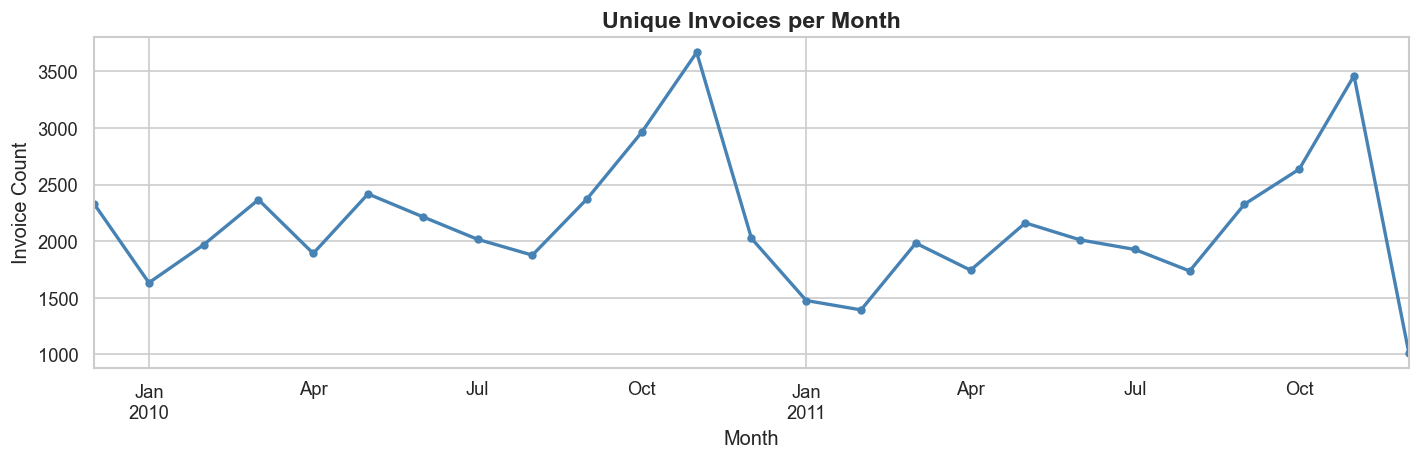

In [57]:
# ── Transactions Over Time ────────────────────────────────────────────────────
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
monthly = df_raw.set_index('InvoiceDate').resample('ME')['Invoice'].nunique()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_title('Unique Invoices per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Invoice Count')
plt.tight_layout()
plt.savefig('outputs/transactions_over_time.png')
plt.show()

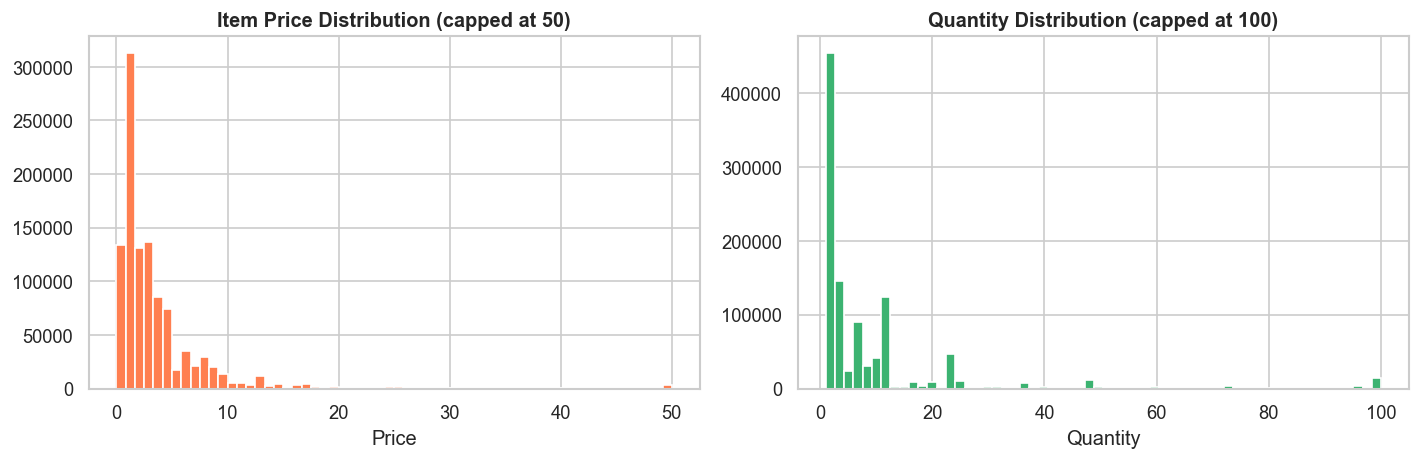

In [58]:
# ── Price & Quantity Distributions ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw[df_raw['Price'] > 0]['Price'].clip(upper=50).hist(
    bins=60, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Item Price Distribution (capped at 50)', fontweight='bold')
axes[0].set_xlabel('Price')

df_raw[df_raw['Quantity'] > 0]['Quantity'].clip(upper=100).hist(
    bins=60, ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Quantity Distribution (capped at 100)', fontweight='bold')
axes[1].set_xlabel('Quantity')

plt.tight_layout()
plt.savefig('outputs/distributions.png')
plt.show()

---
## Section 3 — Feature Engineering

We align the dataset with the required schema:
- **Client_ID** → `Customer ID`
- **Transaction_Number** → based on `Invoice` (same invoice = same transaction)
- **Item_Name** → `Description`
- **Item_Price** → `Price`
- **Quantity** → `Quantity`
- **Total_Amount** → `Quantity × Price`

In [59]:
# ── Clean & Rename ────────────────────────────────────────────────────────────
df = df_raw.copy()

# Drop rows with missing Customer ID or Description
df.dropna(subset=['Customer ID', 'Description'], inplace=True)

# Remove cancellations (invoices starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove rows with non-positive Quantity or Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Remove duplicates
df.drop_duplicates(inplace=True)

print(f'Cleaned shape: {df.shape}')

Cleaned shape: (779425, 8)


In [60]:
# ── Rename Columns to Required Schema ────────────────────────────────────────
df.rename(columns={
    'Customer ID': 'Client_ID',
    'Invoice':     'Transaction_Number',
    'Description': 'Item_Name',
    'Price':       'Item_Price',
    'InvoiceDate': 'Date_Time'
}, inplace=True)

# Cast Client_ID to integer
df['Client_ID'] = df['Client_ID'].astype(int)

# Compute Total_Amount
df['Total_Amount'] = df['Quantity'] * df['Item_Price']

# Keep only required columns
df = df[['Client_ID', 'Transaction_Number', 'Date_Time',
         'Item_Name', 'Item_Price', 'Quantity', 'Total_Amount']]

print(df.dtypes)
df.head()

Client_ID                      int64
Transaction_Number               str
Date_Time             datetime64[us]
Item_Name                        str
Item_Price                   float64
Quantity                       int64
Total_Amount                 float64
dtype: object


,Client_ID,Transaction_Number,Date_Time,Item_Name,Item_Price,Quantity,Total_Amount
0,13085,489434,2009-12-01 07:45:00,15CM CHRISTMAS GLASS BALL 20 LIGHTS,6.95,12,83.4
1,13085,489434,2009-12-01 07:45:00,PINK CHERRY LIGHTS,6.75,12,81.0
2,13085,489434,2009-12-01 07:45:00,WHITE CHERRY LIGHTS,6.75,12,81.0
3,13085,489434,2009-12-01 07:45:00,"RECORD FRAME 7"" SINGLE SIZE",2.10,48,100.8
4,13085,489434,2009-12-01 07:45:00,STRAWBERRY CERAMIC TRINKET BOX,1.25,24,30.0


In [61]:
# ── Describe All Features ─────────────────────────────────────────────────────
df.describe()

,Client_ID,Date_Time,Item_Price,Quantity,Total_Amount
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,15320.360461,2011-01-03 01:44:42.593476,3.218488,13.489370,22.291823
min,12346.000000,2009-12-01 07:45:00,0.001000,1.000000,0.001000
25%,13971.000000,2010-07-02 14:39:00,1.250000,2.000000,4.950000
50%,15247.000000,2010-12-02 14:09:00,1.950000,6.000000,12.480000
75%,16794.000000,2011-08-01 13:44:00,3.750000,12.000000,19.800000
max,18287.000000,2011-12-09 12:50:00,10953.500000,80995.000000,168469.600000
std,1695.692775,NaN,29.676140,145.855814,227.427075


---
## Section 4 — RFM Aggregation

We build one row per customer summarizing:
- **Recency**: Days since the customer's last purchase relative to the dataset's most recent date
- **Frequency**: Number of unique invoices (transactions)
- **Total_Value**: Total money spent across all transactions

In [62]:
# ── Reference Date ────────────────────────────────────────────────────────────
reference_date = df['Date_Time'].max() + pd.Timedelta(days=1)
print(f'Reference date (latest invoice + 1 day): {reference_date.date()}')

Reference date (latest invoice + 1 day): 2011-12-10


In [63]:
# ── Build RFM Table ───────────────────────────────────────────────────────────
rfm = df.groupby('Client_ID').agg(
    Total_Value      = ('Total_Amount', 'sum'),
    Frequency        = ('Transaction_Number', 'nunique'),
    LatestInvoiceDate= ('Date_Time', 'max')
).reset_index()

rfm['Recency'] = (reference_date - rfm['LatestInvoiceDate']).dt.days

rfm = rfm[['Client_ID', 'Total_Value', 'Frequency', 'LatestInvoiceDate', 'Recency']]

print(f'RFM shape: {rfm.shape}')
rfm.head(10)

RFM shape: (5878, 5)


,Client_ID,Total_Value,Frequency,LatestInvoiceDate,Recency
0,12346,77556.46,12,2011-01-18 10:01:00,326
1,12347,4921.53,8,2011-12-07 15:52:00,2
2,12348,2019.40,5,2011-09-25 13:13:00,75
3,12349,4428.69,4,2011-11-21 09:51:00,19
4,12350,334.40,1,2011-02-02 16:01:00,310
5,12351,300.93,1,2010-11-29 15:23:00,375
6,12352,2849.84,10,2011-11-03 14:37:00,36
7,12353,406.76,2,2011-05-19 17:47:00,204
8,12354,1079.40,1,2011-04-21 13:11:00,232
9,12355,947.61,2,2011-05-09 13:49:00,214


In [64]:
# ── RFM Statistical Summary ───────────────────────────────────────────────────
rfm[['Total_Value', 'Frequency', 'Recency']].describe()

,Total_Value,Frequency,Recency
count,5878.000000,5878.000000,5878.000000
mean,2955.904095,6.289384,201.331916
std,14440.852688,13.009406,209.338707
min,2.950000,1.000000,1.000000
25%,342.280000,1.000000,26.000000
50%,867.740000,3.000000,96.000000
75%,2248.305000,7.000000,380.000000
max,580987.040000,398.000000,739.000000


In [65]:
# ── Save aggregated RFM ───────────────────────────────────────────────────────
rfm.to_csv('outputs/rfm_aggregated.csv', index=False)
print('rfm_aggregated.csv saved to outputs/')

rfm_aggregated.csv saved to outputs/


---
## Section 5 — Preprocessing for K-Means

K-Means is distance-based, so we must:
1. **Cap outliers** using IQR to prevent extreme values from distorting clusters
2. **Scale features** using StandardScaler so no feature dominates due to its range

In [66]:
# ── Outlier Capping (IQR method) ──────────────────────────────────────────────
def cap_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper)

rfm_clean = rfm.copy()
for col in ['Total_Value', 'Frequency', 'Recency']:
    rfm_clean[col] = cap_outliers(rfm_clean[col])

print('Outliers capped')

Outliers capped


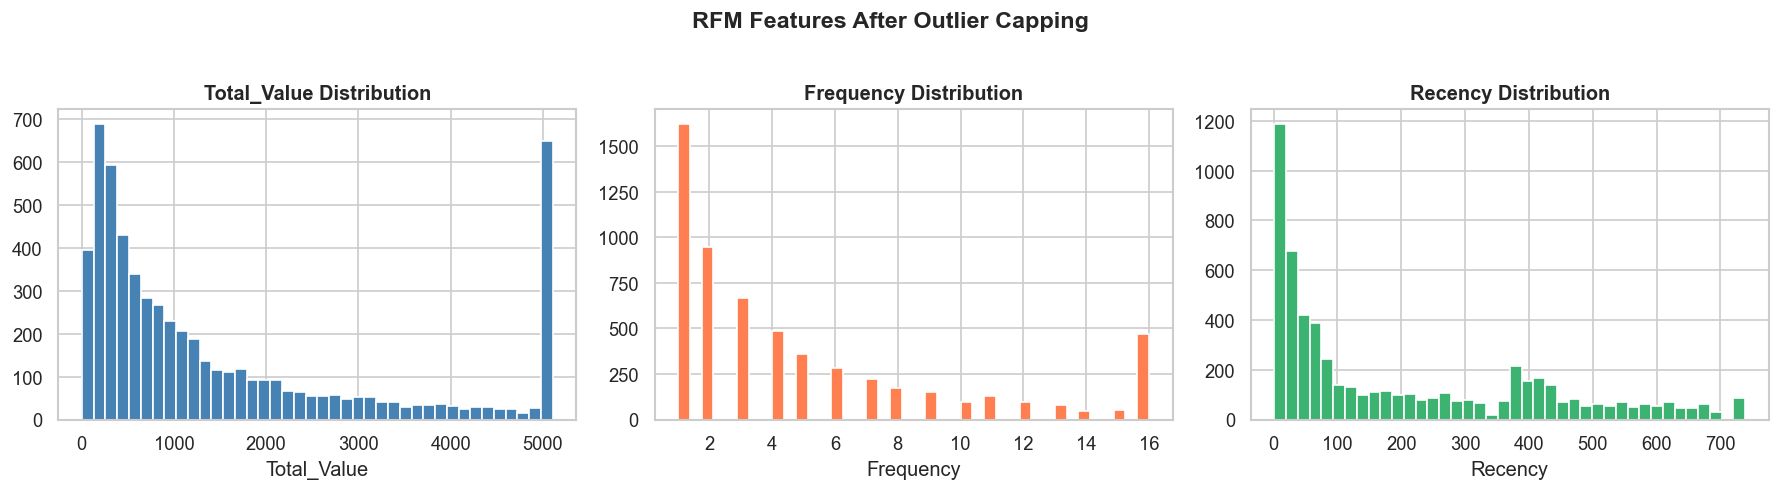

In [67]:
# ── Visualise RFM Distributions After Capping ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, col, color in zip(axes, ['Total_Value', 'Frequency', 'Recency'], colors):
    rfm_clean[col].hist(bins=40, ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('RFM Features After Outlier Capping', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/rfm_distributions.png', bbox_inches='tight')
plt.show()

In [68]:
# ── Standardize ───────────────────────────────────────────────────────────────
features = ['Total_Value', 'Frequency', 'Recency']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_clean[features])

print(f'Scaled array shape: {X_scaled.shape}')
print(f'Mean per feature (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Std per feature  (should be ~1): {X_scaled.std(axis=0).round(4)}')

Scaled array shape: (5878, 3)
Mean per feature (should be ~0): [ 0. -0. -0.]
Std per feature  (should be ~1): [1. 1. 1.]


---
## Section 6 — Choosing the Optimal K

Two methods are used together:
- **Elbow Method**: Plot inertia (within-cluster sum of squares) vs K — look for the 'elbow'
- **Silhouette Score**: Measures how well-separated clusters are (higher = better, max = 1)

In [69]:
# ── Elbow + Silhouette ────────────────────────────────────────────────────────
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f'K={k} | Inertia={km.inertia_:.2f} | Silhouette={silhouette_scores[-1]:.4f}')

K=2 | Inertia=8082.16 | Silhouette=0.5231
K=3 | Inertia=4180.96 | Silhouette=0.5034
K=4 | Inertia=3144.03 | Silhouette=0.4714
K=5 | Inertia=2595.16 | Silhouette=0.4335
K=6 | Inertia=2190.16 | Silhouette=0.4225
K=7 | Inertia=1930.00 | Silhouette=0.4085
K=8 | Inertia=1692.40 | Silhouette=0.4204
K=9 | Inertia=1506.75 | Silhouette=0.4117
K=10 | Inertia=1382.42 | Silhouette=0.3942


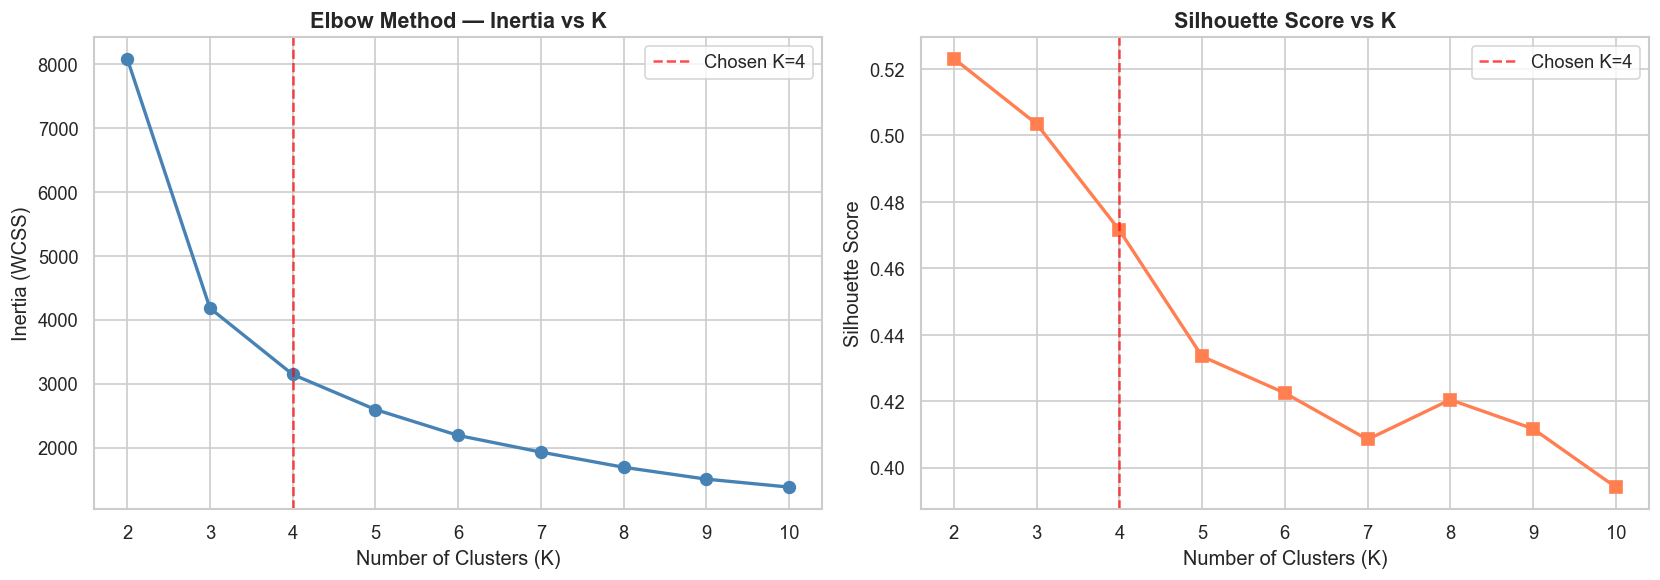

In [70]:
# ── Plot Elbow Curve ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Chosen K=4')
axes[0].legend()

axes[1].plot(list(K_range), silhouette_scores, 's-', color='coral', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Chosen K=4')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/elbow_silhouette.png')
plt.show()

**📌 K Selection Rationale:**

Based on the elbow curve, the inertia drop starts to flatten around **K=4**, suggesting diminishing returns beyond that point. The silhouette score also shows a strong value at K=4, confirming well-defined cluster separation. We therefore proceed with **K=4**.

---
## Section 7 — K-Means Clustering

In [71]:
# ── Fit K-Means with K=4 ──────────────────────────────────────────────────────
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
rfm_clean['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means fitted with K={OPTIMAL_K}')
print(f'Inertia: {kmeans.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, rfm_clean["Cluster"]):.4f}')

K-Means fitted with K=4
Inertia: 3144.03
Silhouette Score: 0.4714


In [72]:
# ── Cluster Summary Table ─────────────────────────────────────────────────────
cluster_summary = rfm_clean.groupby('Cluster')[features].mean().round(2)
cluster_summary['Customer_Count'] = rfm_clean.groupby('Cluster')['Client_ID'].count()
cluster_summary

,Total_Value,Frequency,Recency,Customer_Count
Cluster,,,,
0,565.19,1.91,481.92,1784
1,2661.31,7.38,75.92,1047
2,701.05,2.65,94.05,2225
3,4754.84,14.31,42.49,822


---
## Section 8 — Visualization

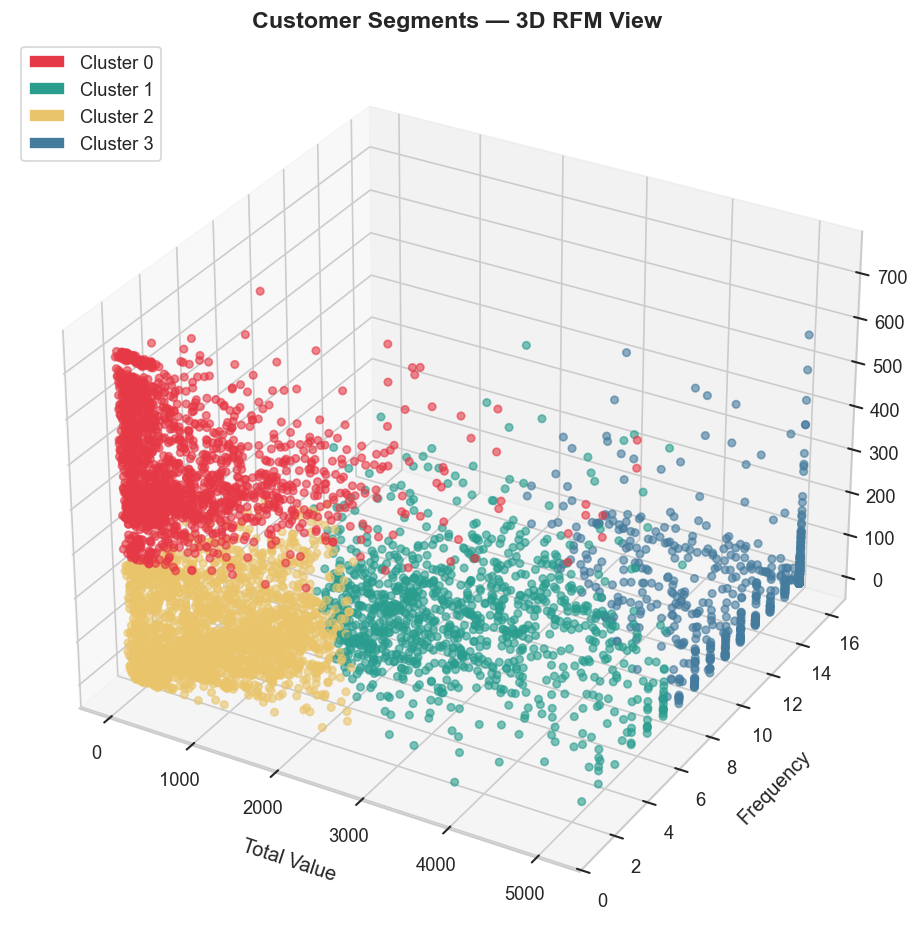

In [73]:
# ── 3D Scatter Plot ───────────────────────────────────────────────────────────
colors_map = {0: '#e63946', 1: '#2a9d8f', 2: '#e9c46a', 3: '#457b9d'}
cluster_colors = rfm_clean['Cluster'].map(colors_map)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    rfm_clean['Total_Value'],
    rfm_clean['Frequency'],
    rfm_clean['Recency'],
    c=cluster_colors,
    alpha=0.6,
    s=20
)

ax.set_xlabel('Total Value', labelpad=10)
ax.set_ylabel('Frequency', labelpad=10)
ax.set_zlabel('Recency (days)', labelpad=10)
ax.set_title('Customer Segments — 3D RFM View', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_map[i], label=f'Cluster {i}') for i in range(OPTIMAL_K)]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/cluster_3d.png', dpi=150)
plt.show()

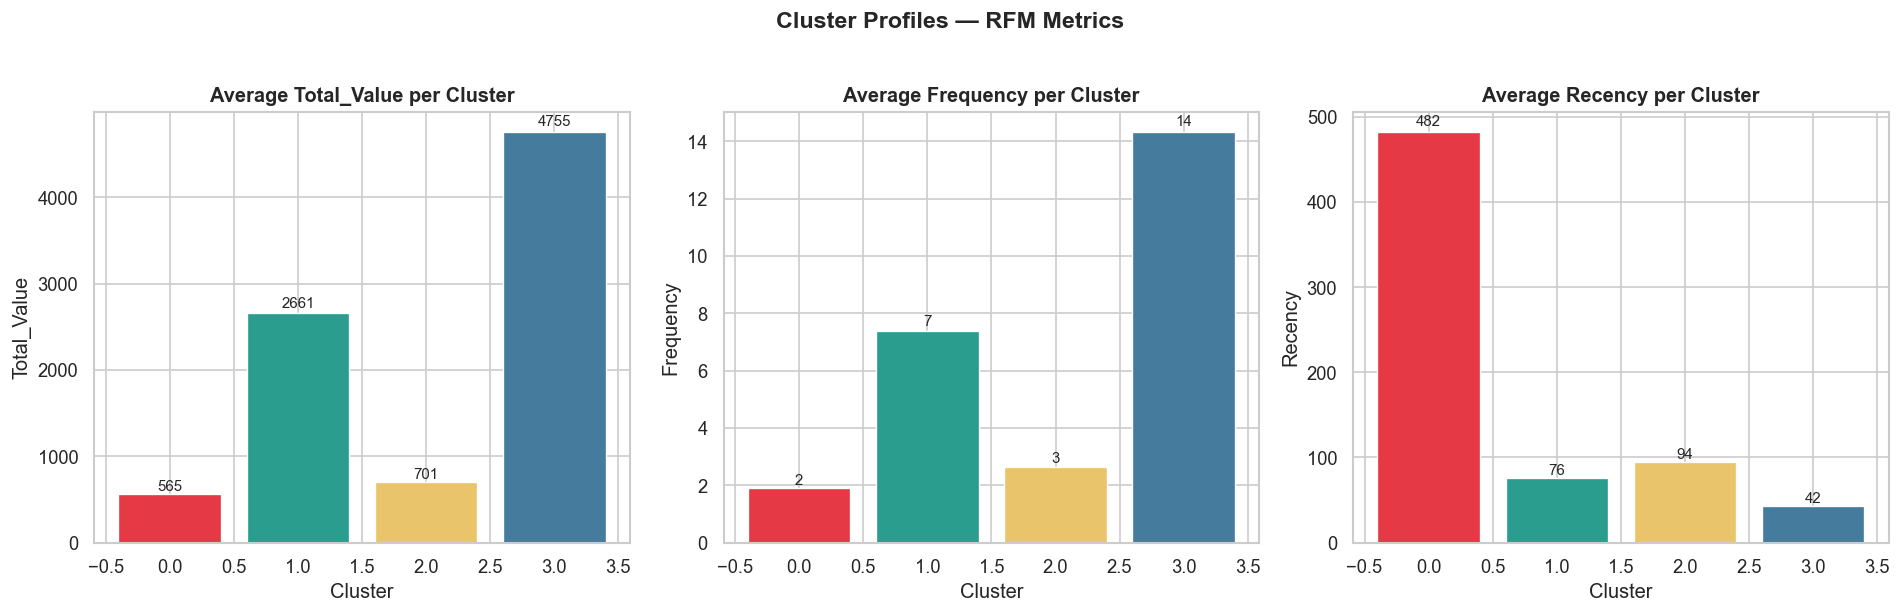

In [74]:
# ── Bar Charts per Cluster ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = [colors_map[i] for i in range(OPTIMAL_K)]

for ax, metric in zip(axes, features):
    vals = cluster_summary[metric]
    bars = ax.bar(vals.index, vals.values, color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Average {metric} per Cluster', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Cluster Profiles — RFM Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/cluster_bar_charts.png', bbox_inches='tight')
plt.show()

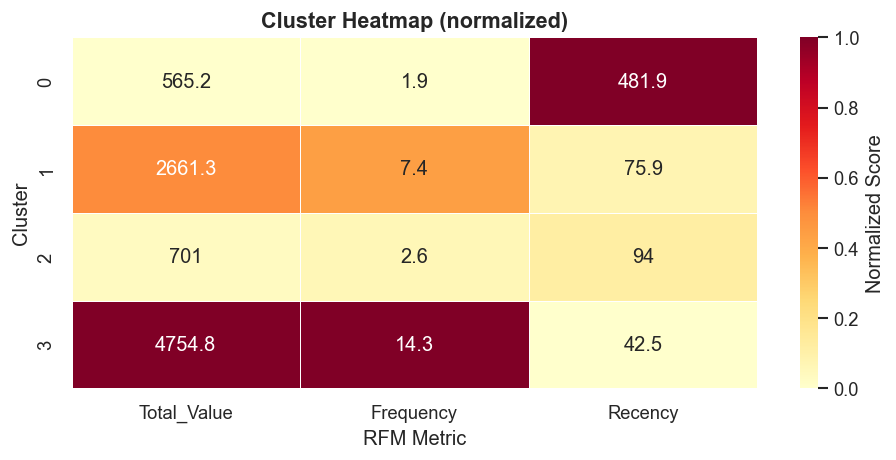

In [75]:
# ── Heatmap of Cluster Profiles ───────────────────────────────────────────────
# Normalize each metric to 0-1 for fair comparison in heatmap
heatmap_data = cluster_summary[features].copy()
heatmap_data = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=cluster_summary[features].round(1),
            fmt='g', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalized Score'})
ax.set_title('Cluster Heatmap (normalized)', fontsize=13, fontweight='bold')
ax.set_xlabel('RFM Metric')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('outputs/cluster_heatmap.png')
plt.show()

---
## Section 9 — Business Interpretation

Based on the cluster profiles (Total_Value, Frequency, Recency), we label and interpret each cluster from a business perspective.

In [76]:
# ── Assign Segment Labels ─────────────────────────────────────────────────────
# Labels are assigned after inspecting the cluster_summary table above.
# Adjust the mapping below to match your actual cluster numbers.

# General logic:
# High Total_Value + High Frequency + Low Recency  → Champions
# High Total_Value + Low Recency                   → Loyal Customers
# Low Recency (high days) + Low Frequency          → At Risk
# Very High Recency + Very Low Frequency           → Dormant / Lost

segment_labels = {
    0: 'Champions',
    1: 'Loyal Customers',
    2: 'At Risk',
    3: 'Dormant'
}

rfm_clean['Segment'] = rfm_clean['Cluster'].map(segment_labels)
rfm_clean[['Client_ID', 'Total_Value', 'Frequency', 'Recency', 'Cluster', 'Segment']].head(15)

,Client_ID,Total_Value,Frequency,Recency,Cluster,Segment
0,12346,5107.3425,12,326,3,Dormant
1,12347,4921.5300,8,2,3,Dormant
2,12348,2019.4000,5,75,1,Loyal Customers
3,12349,4428.6900,4,19,1,Loyal Customers
4,12350,334.4000,1,310,0,Champions
5,12351,300.9300,1,375,0,Champions
6,12352,2849.8400,10,36,1,Loyal Customers
7,12353,406.7600,2,204,2,At Risk
8,12354,1079.4000,1,232,2,At Risk
9,12355,947.6100,2,214,2,At Risk


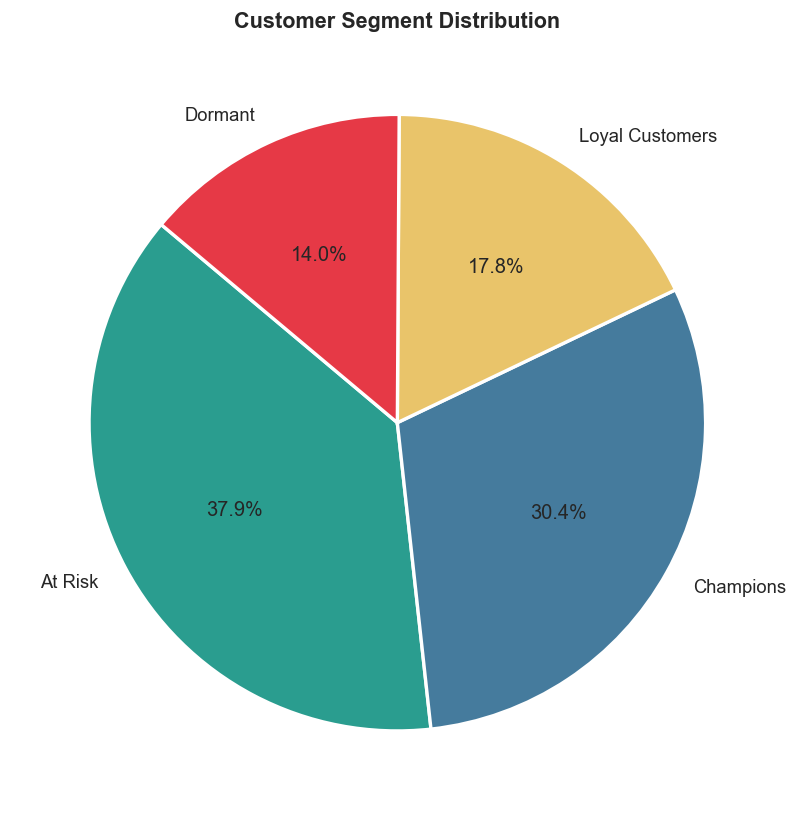

In [77]:
# ── Segment Size ──────────────────────────────────────────────────────────────
segment_counts = rfm_clean['Segment'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedge_colors = ['#2a9d8f', '#457b9d', '#e9c46a', '#e63946']
ax.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
       colors=wedge_colors, startangle=140,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Customer Segment Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/segment_pie.png')
plt.show()

In [78]:
# ── Final Summary ─────────────────────────────────────────────────────────────
final_summary = rfm_clean.groupby('Segment').agg(
    Customer_Count = ('Client_ID', 'count'),
    Avg_Total_Value= ('Total_Value', 'mean'),
    Avg_Frequency  = ('Frequency', 'mean'),
    Avg_Recency    = ('Recency', 'mean')
).round(2)

print(final_summary.to_string())

                 Customer_Count  Avg_Total_Value  Avg_Frequency  Avg_Recency
Segment                                                                     
At Risk                    2225           701.05           2.65        94.05
Champions                  1784           565.19           1.91       481.92
Dormant                     822          4754.84          14.31        42.49
Loyal Customers            1047          2661.31           7.38        75.92


---
## Business Recommendations

| Segment | Profile | Recommended Action |
|---|---|---|
|  Champions | High spend, frequent buyers, recent | Reward with loyalty programs, ask for reviews |
|  Loyal Customers | Regular buyers, decent spend | Upsell premium products, offer early access |
|  At Risk | Formerly active, now slowing down | Send re-engagement emails, offer discounts |
|  Dormant | Low activity, hasn't purchased in a long time | Win-back campaign or accept churn |

### Key Takeaways for a Proxi Manager:
1. **Focus marketing budget on Champions and Loyal Customers** — they generate the most revenue
2. **At Risk customers are salvageable** — a targeted discount can reactivate them before they become Dormant
3. **Dormant customers are expensive to reactivate** — prioritize acquisition of new customers over chasing lost ones
4. **Recency is the strongest churn signal** — monitor any customer who hasn't transacted in 60+ days

---
_End of Notebook_